In [31]:
import os
import time
from collections import defaultdict
import pickle
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

import yaml

from evaluators import evaluation, valid
from training import OracleTrainer
from training.logger import Logger

import utils
from utils import *

In [32]:
MODEL_CONFIG = {
    'embedding_dim': 200,
    'dropout': 0.5,
    'alpha': 0.2,
    'lambdax': 10,
    'oracle_mode': 'soft',
    'filtering': True,
}

TRAINING_CONFIG = {
    'dataset_name': 'YAGO',  # Change to: 'GDELT', 'ICEWS14', 'ICEWS18', 'WIKI'
    'batch_size': 1024,
    'max_epochs': 30,
    'oracle_epochs': 20,
    'valid_epochs': 5,
    'lr': 0.001,
    'oracle_lr': 0.001,
    'weight_decay': 1.0e-05,
    'use_seed': True,
    'seed': 987,
}

SYSTEM_CONFIG = {
    'gpu_id': '0',
    'use_cuda': True,
    'only_oracle': False,
    'only_eva': False,
    'save_dir': 'SAVE',
    'model_dir': '',
}

DATASET_CONFIGS = {
    'YAGO': {
        'dataset': 'YAGO',
        'description': 'yago_hard',
        'model': {
            'alpha': 0.2,
            'lambdax': 2,
            'oracle_mode': 'hard',
        }
    },
    'GDELT': {
        'dataset': 'GDELT',
        'description': 'gdelt_default',
    },
    'ICEWS14': {
        'dataset': 'ICEWS14',
        'description': 'icews14_default',
    },
    'ICEWS18': {
        'dataset': 'ICEWS18',
        'description': 'icews18_default',
        'model': {
            'alpha': 0.2,
            'lambdax': 2,
            'oracle_mode': 'soft',
        }
    },
    'WIKI': {
        'dataset': 'WIKI',
        'description': 'wiki_default',
    },
}

In [33]:
class TKGDataset(Dataset):
    def __init__(self, dataset: str = "YAGO"):
        super().__init__()
        self.dataset_name = dataset
        self.data_path = os.path.join('./data', dataset)
        
        self._load_statistics()
        self._load_split_data('train')
        self.has_valid = self._load_split_data('dev', required=False)
        self._load_split_data('test')
        self._load_total_data()

    def _load_statistics(self):
        self.num_nodes, self.num_rels, self.num_t = utils.get_total_number(
            self.data_path, 'stat.txt'
        )

    def _load_file(self, filename: str):
        filepath = os.path.join(self.data_path, filename)
        with open(filepath, 'rb') as f:
            if filename.endswith('frequency.txt') and self.dataset_name == 'GDELT':
                return torch.load(f).toarray()
            data = pickle.load(f)
            if hasattr(data, 'toarray'):
                return data.toarray()
            return data

    def _load_split_data(self, split: str, required: bool = True) -> bool:
        try:
            quadruple_file = f'{split}.txt' if split != 'dev' else 'valid.txt'
            data, _ = utils.load_quadruples(self.data_path, quadruple_file)
            setattr(self, f'{split}_data', data)
            
            for abbr, entity_type in [('sub', 's'), ('ob', 'o')]:
                history_list = self._load_file(f'{split}_history_{abbr}.txt')
                setattr(self, f'{split}_{entity_type}_history', history_list[0])
                setattr(self, f'{split}_{entity_type}_history_t', history_list[1])
            
            for entity_type in ['s', 'o']:
                label_data = self._load_file(f'{split}_{entity_type}_label.txt')
                setattr(self, f'{split}_{entity_type}_label', label_data)

            for entity_type in ['s', 'o']:
                frequency_data = self._load_file(f'{split}_{entity_type}_frequency.txt')
                setattr(self, f'{split}_{entity_type}_frequency', frequency_data)
            
            return True
            
        except (FileNotFoundError, Exception) as e:
            if required:
                raise
            print(f"{self.dataset_name} does not have {split} set: {e}")
            for attr in ['data', 's_history', 's_history_t', 'o_history', 'o_history_t',
                        's_label', 'o_label', 's_frequency', 'o_frequency']:
                setattr(self, f'{split}_{attr}', None)
            return False

    def _load_total_data(self):
        try:
            splits = ['train.txt', 'valid.txt', 'test.txt'] if self.has_valid else ['train.txt', 'test.txt']
            self.total_data, _ = utils.load_quadruples(self.data_path, *splits)
        except Exception as e:
            print(f"Error loading total data for {self.dataset_name}: {e}")
        
        self.data = self.total_data

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int):
        return self.data[idx]

class TKGDataLoader:
    def __init__(self, dataset, mode, batch_size):
        self.quadruples = getattr(dataset, f'{mode}_data')
        self.s_history = getattr(dataset, f'{mode}_s_history')
        self.o_history = getattr(dataset, f'{mode}_o_history')
        self.s_label = getattr(dataset, f'{mode}_s_label')
        self.o_label = getattr(dataset, f'{mode}_o_label')
        self.s_frequency = getattr(dataset, f'{mode}_s_frequency')
        self.o_frequency = getattr(dataset, f'{mode}_o_frequency')
        self.batch_size = batch_size
        self.num_samples = len(self.quadruples)
        self.num_batches = (self.num_samples + batch_size - 1) // batch_size
    
    def __iter__(self):
        for i in range(0, self.num_samples, self.batch_size):
            end_idx = min(i + self.batch_size, self.num_samples)
            yield [
                torch.from_numpy(self.quadruples[i:end_idx]),
                self.s_history[i:end_idx],
                self.o_history[i:end_idx],
                torch.from_numpy(self.s_label[i:end_idx]).float(),
                torch.from_numpy(self.o_label[i:end_idx]).float(),
                torch.from_numpy(self.s_frequency[i:end_idx]).float(),
                torch.from_numpy(self.o_frequency[i:end_idx]).float()
            ]
    
    def __len__(self):
        return self.num_batches

In [34]:
class Trainer:
    def __init__(self, model, optimizer, training_config, dataset, num_relations, num_nodes, num_t,
                 save_dir='SAVE', dataset_name='YAGO', use_cuda=True, device=None):
        self.model = model
        self.optimizer = optimizer
        self.tkg_dataset = dataset
        self.num_relations = num_relations
        self.num_nodes = num_nodes
        self.num_t = num_t
        self.use_cuda = use_cuda
        self.device = device
        self.dataset_name = dataset_name
        self.gpu_id = training_config.get('gpu_id', '0')

        self.device_str = f'cuda:{self.gpu_id}' if use_cuda else 'cpu'

        # Store training config parameters
        self.batch_size = training_config.get('batch_size', 1024)
        self.max_epochs = training_config.get('max_epochs', 30)
        self.valid_epochs = training_config.get('valid_epochs', 5)

        self.logger = Logger(save_dir, dataset_name)
        self.main_dir = self.logger.get_log_dir()
        self.model_path = os.path.join(self.main_dir, 'models')

        os.makedirs(self.model_path, exist_ok=True)

    def __del__(self):
        if hasattr(self, 'logger') and self.logger:
            self.logger.close()

    def _move_batch_to_device(self, batch_data):
        return [
            batch_data[0].to(self.device),  # quadruples
            batch_data[1],                   # s_history
            batch_data[2],                   # o_history
            batch_data[3].to(self.device),  # s_label
            batch_data[4].to(self.device),  # o_label
            batch_data[5].to(self.device),  # s_frequency
            batch_data[6].to(self.device)   # o_frequency
        ]

    def log_config(self, model_config, training_config, system_config):
        self.logger.log_config(model_config, training_config, system_config)

    def log_model_info(self):
        self.logger.log_model_info(self.model, self.device_str)

    def train(self, train_loader, valid_loader):
        best_mrr = 0

        for epoch in range(1, self.max_epochs + 1):
            self.model.train()
            self.logger.log_epoch_start(epoch, self.max_epochs)

            loss_epoch = 0
            batch_count = 0
            time_begin = time.time()

            pbar = tqdm(train_loader, total=len(train_loader),
                        desc=f"Training Epoch {epoch}", unit='batch')

            for batch_data in pbar:
                batch_data = self._move_batch_to_device(batch_data)

                # giải phóng memory tốt hơn so với zero_grad() mặc định
                self.optimizer.zero_grad(set_to_none=True)

                loss = self.model(batch_data, 'Training')
                if loss is None:
                    continue

                loss_item = loss.item()
                loss.backward()
                self.optimizer.step()

                loss_epoch += loss_item
                batch_count += 1
                avg_loss_batch = loss_epoch / batch_count
                pbar.set_postfix({
                    'loss': f'{loss_item:.4f}',
                    'avg_loss': f'{avg_loss_batch:.4f}'
                })

            epoch_time = time.time() - time_begin
            avg_loss = loss_epoch / batch_count if batch_count > 0 else 0
            self.logger.log_train_epoch(epoch, avg_loss, epoch_time)

            if self.use_cuda:
                self.logger.log_gpu_memory(self.device_str)

            if epoch % self.valid_epochs == 0 and self.dataset_name != 'ICEWS14T':
                best_mrr, val_loss = self._validate(epoch, best_mrr, valid_loader)
                self.logger.log_metrics(epoch, avg_loss, val_loss)
            else:
                self.logger.log_metrics(epoch, avg_loss)

        self.logger.log_training_completed()
        # Đóng file CSV / logger sau khi training xong
        self.logger.close()

        return self.model_path

    def get_logger(self):
        return self.logger

    def _validate(self, epoch, best_mrr, valid_loader):
        """
        Run validation. Expects `valid_loader` to be prepared externally.
        """
        self.logger.log_validation_start(epoch)
        # Convert total_data to tensor on device once
        total_data_tensor = torch.from_numpy(self.tkg_dataset.total_data).to(self.device)

        # Use the evaluator function that consumes an external loader
        s_ranks2, o_ranks2, all_ranks2, s_ranks3, o_ranks3, all_ranks3, val_loss = valid.execute_valid(
            self.batch_size,
            total_data_tensor,
            self.model,
            valid_loader,
            device=self.device
        )

        raw_mrr, oracle_mrr = self.logger.log_validation_metrics(
            s_ranks2, o_ranks2, all_ranks2,
            s_ranks3, o_ranks3, all_ranks3
        )

        if oracle_mrr > best_mrr:
            best_mrr = oracle_mrr
            best_model_path = os.path.join(self.model_path, f'{self.dataset_name}_best.pth')
            torch.save(self.model.state_dict(), best_model_path)
            self.logger.log_model_improved(oracle_mrr)
        else:
            self.logger.log_model_not_improved(best_mrr, oracle_mrr)

        return best_mrr, val_loss

In [35]:
class Oracle(nn.Module):
    def __init__(self, input_dim, out_dim):
        super(Oracle, self).__init__()
        self.linear = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2),
            nn.Linear(input_dim, out_dim)
        )

    def forward(self, x):
        return self.linear(x)

In [36]:
class CENET(nn.Module):
    def __init__(self, num_e, num_rel, num_t, embedding_dim, dropout, lambdax, alpha, oracle_mode, filtering):
        super(CENET, self).__init__()
        # stats
        self.num_e = num_e
        self.num_t = num_t
        self.num_rel = num_rel
        self.embedding_dim = embedding_dim
        self.lambdax = lambdax
        self.alpha = alpha
        self.oracle_mode = oracle_mode
        self.filtering = filtering

        # Precomputed triple indexes.
        self._so_index: dict = {}
        self._os_index: dict = {}
        self._so_index_device_cache: dict = {}
        self._os_index_device_cache: dict = {}

        # entity relation embedding
        self.rel_embeds = nn.Parameter(torch.zeros(2 * num_rel, embedding_dim))
        self.entity_embeds = nn.Parameter(torch.zeros(self.num_e, embedding_dim))

        self.linear_frequency = nn.Linear(self.num_e, embedding_dim)

        self.contrastive_hidden_layer = nn.Linear(3 * embedding_dim, embedding_dim)
        self.oracle_layer = Oracle(3 * embedding_dim, 1)

        self.linear_pred_layer_s1 = nn.Linear(2 * embedding_dim, embedding_dim)
        self.linear_pred_layer_o1 = nn.Linear(2 * embedding_dim, embedding_dim)

        self.linear_pred_layer_s2 = nn.Linear(2 * embedding_dim, embedding_dim)
        self.linear_pred_layer_o2 = nn.Linear(2 * embedding_dim, embedding_dim)

        # Initialize weights and embeddings
        self.reset_parameters()

        self.dropout = nn.Dropout(dropout)
        self.tanh = nn.Tanh()
        self.crossEntropy = nn.BCELoss()

    def reset_parameters(self):
        gain = nn.init.calculate_gain('relu')

        # Initialize embeddings
        nn.init.xavier_uniform_(self.rel_embeds, gain=gain)
        nn.init.xavier_uniform_(self.entity_embeds, gain=gain)

        # Initialize layers
        self.weights_init(self.linear_frequency)
        self.weights_init(self.linear_pred_layer_s1)
        self.weights_init(self.linear_pred_layer_o1)
        self.weights_init(self.linear_pred_layer_s2)
        self.weights_init(self.linear_pred_layer_o2)
        self.oracle_layer.apply(self.weights_init)

    @staticmethod
    def weights_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))

    def build_triple_index(self, all_triples: torch.Tensor):
        so_index: dict = defaultdict(list)
        os_index: dict = defaultdict(list)

        triples_cpu = all_triples.cpu()
        s_col = triples_cpu[:, 0].tolist()
        r_col = triples_cpu[:, 1].tolist()
        o_col = triples_cpu[:, 2].tolist()

        for s, r, o in zip(s_col, r_col, o_col):
            so_index[(s, r)].append(o)
            os_index[(o, r)].append(s)

        self._so_index = {k: torch.tensor(v, dtype=torch.long) for k, v in so_index.items()}
        self._os_index = {k: torch.tensor(v, dtype=torch.long) for k, v in os_index.items()}
        self._so_index_device_cache = {}
        self._os_index_device_cache = {}

    def _get_index_on_device(self, index_name: str, key, device):
        if index_name == 'so':
            index = self._so_index
            cache = self._so_index_device_cache
        else:
            index = self._os_index
            cache = self._os_index_device_cache

        idx = index.get(key, None)
        if idx is None:
            return None

        cache_key = (device.type, device.index, key)
        idx_device = cache.get(cache_key, None)
        if idx_device is None:
            idx_device = idx.to(device, non_blocking=True)
            cache[cache_key] = idx_device
        return idx_device

    def history_and_non_history_depedency(self, s_frequency, o_frequency, lambdax):
        s_history_tag = s_frequency.clone()
        o_history_tag = o_frequency.clone()
        s_non_history_tag = s_frequency.clone()
        o_non_history_tag = o_frequency.clone()

        s_history_tag[s_history_tag != 0] = lambdax
        o_history_tag[o_history_tag != 0] = lambdax

        s_non_history_tag[s_history_tag == 1] = -lambdax
        s_non_history_tag[s_history_tag == 0] = lambdax

        o_non_history_tag[o_history_tag == 1] = -lambdax
        o_non_history_tag[o_history_tag == 0] = lambdax

        s_history_tag[s_history_tag == 0] = -lambdax
        o_history_tag[o_history_tag == 0] = -lambdax

        return s_history_tag, o_history_tag, s_non_history_tag, o_non_history_tag

    def forward(self, batch_block, mode_lk, total_data=None):
        quadruples, s_history_event_o, o_history_event_s, \
        s_history_label_true, o_history_label_true, s_frequency, o_frequency = batch_block

        if isListEmpty(s_history_event_o) or isListEmpty(o_history_event_s):
            return (None, None) if mode_lk in ['Valid', 'Test'] else None

        s, r, o = quadruples[:, :3].T
        s_history_tag, o_history_tag, \
            s_non_history_tag, o_non_history_tag = self.history_and_non_history_depedency(
                s_frequency, o_frequency, self.lambdax)

        s_frequency = F.softmax(s_frequency, dim=1)
        o_frequency = F.softmax(o_frequency, dim=1)
        s_frequency_hidden = self.tanh(self.linear_frequency(s_frequency))
        o_frequency_hidden = self.tanh(self.linear_frequency(o_frequency))
        
        s_embeds = self.entity_embeds[s]
        o_embeds = self.entity_embeds[o]
        s_r_embeds = self.rel_embeds[:self.num_rel][r]
        o_r_embeds = self.rel_embeds[self.num_rel:][r]

        if mode_lk == 'Training':
            s_nce_loss, _ = self.calculate_nce_loss(s_embeds, o, s_r_embeds,
                                                    self.linear_pred_layer_s1, self.linear_pred_layer_s2,
                                                    s_history_tag, s_non_history_tag, return_preds=False)
            o_nce_loss, _ = self.calculate_nce_loss(o_embeds, s, o_r_embeds,
                                                    self.linear_pred_layer_o1, self.linear_pred_layer_o2,
                                                    o_history_tag, o_non_history_tag, return_preds=False)
            s_spc_loss = self.calculate_spc_loss(s_embeds, s_r_embeds, s_history_label_true, s_frequency_hidden)
            o_spc_loss = self.calculate_spc_loss(o_embeds, o_r_embeds, o_history_label_true, o_frequency_hidden)
            nce_loss = (s_nce_loss + o_nce_loss) / 2.0
            spc_loss = (s_spc_loss + o_spc_loss) / 2.0
            return self.alpha * nce_loss + (1 - self.alpha) * spc_loss

        elif mode_lk in ['Valid', 'Test']:
            s_history_oid = [
                np.concatenate([con_events[:, 1] for con_events in s_history_event_o[i]]).tolist()
                if len(s_history_event_o[i]) > 0 else []
                for i in range(quadruples.shape[0])
            ]

            o_history_sid = [
                np.concatenate([con_events[:, 1] for con_events in o_history_event_s[i]]).tolist()
                if len(o_history_event_s[i]) > 0 else []
                for i in range(quadruples.shape[0])
            ]

            s_nce_loss, s_preds = self.calculate_nce_loss(s_embeds, o, s_r_embeds,
                                                          self.linear_pred_layer_s1, self.linear_pred_layer_s2, s_history_tag, s_non_history_tag)
            o_nce_loss, o_preds = self.calculate_nce_loss(o_embeds, s, o_r_embeds,
                                                          self.linear_pred_layer_o1, self.linear_pred_layer_o2, o_history_tag, o_non_history_tag)

            s_ce_loss, s_pred_history_label, s_ce_all_acc = self.oracle_loss(s_embeds, s_r_embeds, s_history_label_true, s_frequency_hidden)
            o_ce_loss, o_pred_history_label, o_ce_all_acc = self.oracle_loss(o_embeds, o_r_embeds, o_history_label_true, o_frequency_hidden)

            s_mask = self._build_mask_vectorized(quadruples, s_pred_history_label, s_history_oid)
            o_mask = self._build_mask_vectorized(quadruples, o_pred_history_label, o_history_sid)

            if self.oracle_mode == 'soft':
                s_mask = F.softmax(s_mask, dim=1)
                o_mask = F.softmax(o_mask, dim=1)

            sub_rank1 = self.link_predict(s_preds, s, o, r, s_mask, total_data, 's', True)
            obj_rank1 = self.link_predict(o_preds, o, s, r, o_mask, total_data, 'o', True)
            batch_loss = (s_nce_loss + s_ce_loss + o_nce_loss + o_ce_loss) / 2.0

            sub_rank2 = self.link_predict(s_preds, s, o, r, s_mask, total_data, 's', False)
            obj_rank2 = self.link_predict(o_preds, o, s, r, o_mask, total_data, 'o', False)

            s_mask_gt = self._build_mask_gt_vectorized(quadruples, o, s_history_oid)
            o_mask_gt = self._build_mask_gt_vectorized(quadruples, s, o_history_sid)

            sub_rank3 = self.link_predict(s_preds, s, o, r, s_mask_gt, total_data, 's', True)
            obj_rank3 = self.link_predict(o_preds, o, s, r, o_mask_gt, total_data, 'o', True)

            return batch_loss, sub_rank1, obj_rank1, \
                   sub_rank2, obj_rank2, \
                   sub_rank3, obj_rank3, \
                   (s_ce_all_acc + o_ce_all_acc) / 2

        elif mode_lk == 'Oracle':
            s_ce_loss, _, _ = self.oracle_loss(s_embeds, s_r_embeds, s_history_label_true, s_frequency_hidden)
            o_ce_loss, _, _ = self.oracle_loss(o_embeds, o_r_embeds, o_history_label_true, o_frequency_hidden)
            return (s_ce_loss + o_ce_loss) / 2.0 + self.oracle_l1(0.01)

    def _build_history_mask(self, history_ids: list, device) -> torch.Tensor:
        B = len(history_ids)
        history_mask = torch.zeros(B, self.num_e, device=device)

        row_parts = []
        col_parts = []
        for i, ids in enumerate(history_ids):
            if len(ids) == 0:
                continue
            ids_tensor = torch.as_tensor(ids, dtype=torch.long, device=device)
            row_parts.append(torch.full_like(ids_tensor, i))
            col_parts.append(ids_tensor)

        if row_parts:
            rows = torch.cat(row_parts)
            cols = torch.cat(col_parts)
            history_mask[rows, cols] = 1.0

        return history_mask

    def _build_mask_vectorized(
        self,
        quadruples: torch.Tensor,
        pred_label: torch.Tensor,
        history_ids: list,
    ) -> torch.Tensor:
        device = quadruples.device
        history_mask = self._build_history_mask(history_ids, device)

        is_history = torch.squeeze(pred_label) > 0.5
        if is_history.dim() == 0:
            is_history = is_history.unsqueeze(0)

        return torch.where(is_history.unsqueeze(1), history_mask, 1.0 - history_mask)

    def _build_mask_gt_vectorized(
        self,
        quadruples: torch.Tensor,
        actor2: torch.Tensor,
        history_ids: list,
    ) -> torch.Tensor:
        device = quadruples.device
        history_mask = self._build_history_mask(history_ids, device)
        in_history = history_mask[torch.arange(actor2.shape[0], device=device), actor2].bool()

        return torch.where(in_history.unsqueeze(1), history_mask, 1.0 - history_mask)

    def oracle_loss(self, actor1, r, history_label, frequency_hidden):
        history_label_pred = torch.sigmoid(
            self.oracle_layer(torch.cat((actor1, r, frequency_hidden), dim=1)))
        true_label = torch.squeeze(history_label)
        pred_label = (torch.squeeze(history_label_pred) > 0.5).to(true_label.dtype)
        ce_correct = torch.sum(torch.eq(pred_label, true_label))
        ce_loss = self.crossEntropy(torch.squeeze(history_label_pred), true_label)
        return ce_loss, history_label_pred, ce_correct.item()

    def calculate_nce_loss(
        self,
        actor1,
        actor2,
        r,
        linear1,
        linear2,
        history_tag,
        non_history_tag,
        return_preds=True,
    ):
        preds_raw1 = self.tanh(linear1(
            self.dropout(torch.cat((actor1, r), dim=1))))
        logits1 = preds_raw1.mm(self.entity_embeds.transpose(0, 1)) + history_tag

        preds_raw2 = self.tanh(linear2(
            self.dropout(torch.cat((actor1, r), dim=1))))
        logits2 = preds_raw2.mm(self.entity_embeds.transpose(0, 1)) + non_history_tag

        actor2 = actor2.view(-1, 1)

        if return_preds:
            preds1 = F.softmax(logits1, dim=1)
            preds2 = F.softmax(logits2, dim=1)
            target_prob = torch.gather(preds1, 1, actor2) + torch.gather(preds2, 1, actor2)
            nce = -torch.mean(torch.log(target_prob))
            return nce, preds1 + preds2

        target_logit1 = torch.gather(logits1, 1, actor2)
        target_logit2 = torch.gather(logits2, 1, actor2)
        target_log_prob1 = target_logit1 - torch.logsumexp(logits1, dim=1, keepdim=True)
        target_log_prob2 = target_logit2 - torch.logsumexp(logits2, dim=1, keepdim=True)
        nce = -torch.mean(torch.logaddexp(target_log_prob1, target_log_prob2))
        return nce, None

    def freeze_parameter(self):
        self.rel_embeds.requires_grad_(False)
        self.entity_embeds.requires_grad_(False)
        self.linear_pred_layer_s1.requires_grad_(False)
        self.linear_pred_layer_o1.requires_grad_(False)
        self.linear_pred_layer_s2.requires_grad_(False)
        self.linear_pred_layer_o2.requires_grad_(False)
        self.linear_frequency.requires_grad_(False)
        self.contrastive_hidden_layer.requires_grad_(False)
        self.contrastive_hidden_layer.requires_grad_(False)

    def link_predict(self, preds, actor1, actor2, r, trust_musk, all_triples, pred_known, oracle):
        if oracle:
            preds = torch.mul(preds, trust_musk)

        grounds = preds[torch.arange(preds.shape[0], device=preds.device), actor2]

        if self.filtering:
            if len(self._so_index) == 0 and all_triples is not None:
                self.build_triple_index(all_triples)

            index_name = 'so' if pred_known == 's' else 'os'
            preds = preds.clone()

            actor1_list = actor1.detach().cpu().tolist()
            r_list = r.detach().cpu().tolist()

            for i, (cur_actor1, cur_r) in enumerate(zip(actor1_list, r_list)):
                idx = self._get_index_on_device(index_name, (cur_actor1, cur_r), preds.device)
                if idx is not None and idx.numel() > 0:
                    preds[i].index_fill_(0, idx, 0.0)

            preds[torch.arange(preds.shape[0], device=preds.device), actor2] = grounds

        grounds = grounds.unsqueeze(1)
        comp1 = (preds > grounds).sum(dim=1).float()
        comp2 = (preds == grounds).sum(dim=1).float()
        ranks = (comp1 + (comp2 - 1.0) / 2.0 + 1.0).cpu().tolist()

        return ranks

    def oracle_l1(self, reg_param):
        return reg_param * sum(param.abs().sum() for param in self.oracle_layer.parameters())

    def contrastive_layer(self, x):
        x = self.contrastive_hidden_layer(x)
        return x

    def calculate_spc_loss(self, actor1, r, targets, frequency_hidden):
        projections = self.contrastive_layer(
            torch.cat((actor1, r, frequency_hidden), dim=1))
        targets = torch.squeeze(targets)
        dot_product_tempered = torch.mm(projections, projections.T) / 1.0
        exp_dot_tempered = torch.exp(
            dot_product_tempered - torch.max(dot_product_tempered, dim=1, keepdim=True)[0]) + 1e-5
        mask_similar_class = targets.unsqueeze(1) == targets.unsqueeze(0)
        mask_anchor_out = ~torch.eye(exp_dot_tempered.shape[0], dtype=torch.bool, device=projections.device)
        mask_combined = mask_similar_class * mask_anchor_out
        cardinality_per_samples = torch.sum(mask_combined, dim=1)
        log_prob = -torch.log(exp_dot_tempered / (torch.sum(exp_dot_tempered * mask_anchor_out, dim=1, keepdim=True)))
        supervised_contrastive_loss_per_sample = torch.sum(log_prob * mask_combined, dim=1) / cardinality_per_samples

        supervised_contrastive_loss = torch.mean(supervised_contrastive_loss_per_sample)
        if torch.any(torch.isnan(supervised_contrastive_loss)):
            return 0
        return supervised_contrastive_loss

In [37]:
# Extract dataset name from config
dataset_name = TRAINING_CONFIG['dataset_name']

# Get configs from dictionaries by passing them as parameters
model_config, training_config, system_config = get_configs(
    dataset_name, 
    MODEL_CONFIG, 
    TRAINING_CONFIG, 
    SYSTEM_CONFIG, 
    DATASET_CONFIGS
)

# Setup GPU/CPU
use_cuda = system_config['use_cuda'] and torch.cuda.is_available()
system_config['use_cuda'] = use_cuda
device = torch.device(f'cuda:{system_config["gpu_id"]}' if use_cuda else 'cpu')

# Setup seed if enabled
if training_config['use_seed']:
    seed = training_config['seed']
    np.random.seed(seed)
    torch.manual_seed(seed)
    print(f"Seed set to: {seed}")

# Setup directories
os.makedirs(system_config['save_dir'], exist_ok=True)

print(f"Dataset: {system_config['dataset']}")
print(f"Device: {device}")
print(f"CUDA available: {use_cuda}")

Seed set to: 987
Dataset: YAGO
Device: cuda:0
CUDA available: True


In [38]:
dataset = TKGDataset(system_config['dataset'])
num_nodes = dataset.num_nodes
num_rels = dataset.num_rels
num_t = dataset.num_t

print(f"Nodes: {num_nodes}, Relations: {num_rels}, Timestamps: {num_t}")

Nodes: 10623, Relations: 10, Timestamps: 189


In [39]:
train_loader = TKGDataLoader(dataset, "train", training_config['batch_size'])
valid_loader = TKGDataLoader(dataset, "dev", training_config['batch_size'])
test_loader = TKGDataLoader(dataset, "test", training_config['batch_size'])

In [40]:
trainer = None
test_logger = None

if not system_config['only_eva'] and not system_config['only_oracle']:
    # Create model
    model = CENET(
        num_nodes,
        num_rels,
        num_t,
        embedding_dim=model_config['embedding_dim'],
        dropout=model_config['dropout'],
        lambdax=model_config['lambdax'],
        alpha=model_config['alpha'],
        oracle_mode=model_config['oracle_mode'],
        filtering=model_config['filtering'],
    )
    
    # Setup optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=training_config['lr'],
        weight_decay=training_config['weight_decay']
    )
    model = model.to(device)
    
    # Create trainer
    trainer = Trainer(
        model, optimizer, training_config, dataset,
        num_rels, num_nodes, num_t,
        save_dir=system_config['save_dir'],
        dataset_name=system_config['dataset'],
        use_cuda=use_cuda,
        device=device
    )
    trainer.log_config(model_config, training_config, system_config)
    trainer.log_model_info()

    model_path = trainer.train(train_loader, valid_loader)
    main_dirName = os.path.dirname(model_path)
    test_logger = trainer.get_logger()
else:
    # Load existing model
    main_dirName = os.path.join(system_config['save_dir'], system_config['model_dir'])
    model_path = os.path.join(main_dirName, 'models')
    logger_instance = Logger(system_config['save_dir'], system_config['dataset'])
    test_logger = logger_instance
    main_dirName = logger_instance.get_log_dir()

print(f"Model path: {model_path}")

Model Configuration:
  alpha                = 0.2
  dropout              = 0.5
  embedding_dim        = 200
  filtering            = True
  lambdax              = 2
  oracle_mode          = hard
Training Configuration:
  batch_size           = 1024
  dataset_name         = YAGO
  lr                   = 0.001
  max_epochs           = 30
  oracle_epochs        = 20
  oracle_lr            = 0.001
  seed                 = 987
  use_seed             = True
  valid_epochs         = 5
  weight_decay         = 1e-05
System Configuration:
  dataset              = YAGO
  gpu_id               = 0
  model_dir            = 
  only_eva             = False
  only_oracle          = False
  save_dir             = SAVE
  use_cuda             = True

Model Information:
  Total Parameters: 5,056,801
  Trainable Parameters: 5,056,801
  GPU Memory Reserved:  0.78 GB
  GPU Memory Allocated: 0.59 GB
  GPU Memory Peak:      0.59 GB
Epoch 1/30


Training Epoch 1:   0%|          | 0/158 [00:00<?, ?batch/s, loss=5.9007, avg_loss=6.4212]

Training Epoch 1: 100%|██████████| 158/158 [00:06<00:00, 22.67batch/s, loss=5.8425, avg_loss=5.9239]


[TRAIN] Epoch 1: Loss = 5.923944 (Time: 6.97s)
[VRAM] Peak: 0.70GB | Reserved: 0.82GB
Epoch 2/30


Training Epoch 2: 100%|██████████| 158/158 [00:06<00:00, 23.01batch/s, loss=5.7785, avg_loss=5.8129]


...

[TRAIN] Epoch 29: Loss = 5.587081 (Time: 7.99s)
[VRAM] Peak: 0.71GB | Reserved: 0.82GB
Epoch 30/30


Training Epoch 30: 100%|██████████| 158/158 [00:08<00:00, 19.41batch/s, loss=5.5377, avg_loss=5.5863]


[TRAIN] Epoch 30: Loss = 5.586285 (Time: 8.14s)
[VRAM] Peak: 0.71GB | Reserved: 0.82GB
[VALIDATION] Epoch 30


Validating: 100%|██████████| 20/20 [00:04<00:00,  4.46batch/s]

  [No Oracle Filtering]
    Subject test MRR (lk): 0.835102
    Subject test MR (lk): 141.399247
    Subject test Hits (lk) @ 1: 0.820007
    Subject test Hits (lk) @ 3: 0.840752
    Subject test Hits (lk) @ 10: 0.862777
    Object test MRR (lk): 0.830291
    Object test MR (lk): 162.420248
    Object test Hits (lk) @ 1: 0.820366
    Object test Hits (lk) @ 3: 0.832864
    Object test Hits (lk) @ 10: 0.847257
    ALL test MRR (lk): 0.832696
    ALL test MR (lk): 151.909747
    ALL test Hits (lk) @ 1: 0.820186
    ALL test Hits (lk) @ 3: 0.836808
    ALL test Hits (lk) @ 10: 0.855017
  [Ground Truth Oracle]
    Subject test MRR (lk): 0.893510
    Subject test MR (lk): 133.308431
    Subject test Hits (lk) @ 1: 0.887415
    Subject test Hits (lk) @ 3: 0.895201
    Subject test Hits (lk) @ 10: 0.902986
    Object test MRR (lk): 0.889172
    Object test MR (lk): 152.903831
    Object test Hits (lk) @ 1: 0.886698
    Object test Hits (lk) @ 3: 0.888593
    Object test Hits (lk) @ 10: 0.8927

In [41]:
# Create a fresh model instance for oracle training
model = CENET(
    num_nodes,
    num_rels,
    num_t,
    embedding_dim=model_config['embedding_dim'],
    dropout=model_config['dropout'],
    lambdax=model_config['lambdax'],
    alpha=model_config['alpha'],
    oracle_mode=model_config['oracle_mode'],
    filtering=model_config['filtering'],
)
model = model.to(device)

# Load the saved weights
pth_path = os.path.join(model_path, f'{system_config["dataset"]}_best.pth')

checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
model = checkpoint.to(device) if not isinstance(checkpoint, dict) else model
if isinstance(checkpoint, dict):
    model.load_state_dict(checkpoint)

# Ensure model is on the correct device
model = model.to(device)

oracle_trainer = OracleTrainer(
    model, training_config, dataset, model_path,
    dataset_name=system_config['dataset'],
    use_cuda=use_cuda,
    device=device,
    logger=test_logger
)
oracle_trainer.train()

# Save model state_dict (lightweight format)
torch.save(model.state_dict(), os.path.join(model_path, f'{system_config["dataset"]}_best.pth'))
print("Oracle training complete. Model weights saved.")

[ORACLE TRAINING PHASE]
Starting Oracle training...


Oracle Epoch 1:   1%|▏         | 2/158 [00:00<00:10, 15.59batch/s, loss=180.0566, avg_loss=183.5726]

Oracle Epoch 1: 100%|██████████| 158/158 [00:07<00:00, 19.96batch/s, loss=6.3367, avg_loss=46.5549]  


[ORACLE] Epoch 1: Loss = 46.554919 (Time: 7.92s)


Oracle Epoch 2: 100%|██████████| 158/158 [00:07<00:00, 20.77batch/s, loss=5.0607, avg_loss=5.6303]


...

[ORACLE] Epoch 18: Loss = 0.699162 (Time: 7.93s)


Oracle Epoch 19: 100%|██████████| 158/158 [00:07<00:00, 20.23batch/s, loss=0.8426, avg_loss=0.6960]


[ORACLE] Epoch 19: Loss = 0.696012 (Time: 7.81s)


Oracle Epoch 20: 100%|██████████| 158/158 [00:07<00:00, 19.77batch/s, loss=0.8342, avg_loss=0.6952]

[ORACLE] Epoch 20: Loss = 0.695210 (Time: 7.99s)
Oracle training completed!
Oracle training complete. Model weights saved.


In [42]:
if system_config['only_eva']:
    main_dirName = os.path.join(system_config['save_dir'], system_config['model_dir'])
    model_path = os.path.join(main_dirName, 'models')

test_logger.write("[TEST PHASE]")
test_logger.write("Testing starts...")

time_begin = time.time()

# Khởi tạo model với cấu trúc đúng
model = CENET(
    num_nodes,
    num_rels,
    num_t,
    embedding_dim=model_config['embedding_dim'],
    dropout=model_config['dropout'],
    lambdax=model_config['lambdax'],
    alpha=model_config['alpha'],
    oracle_mode=model_config['oracle_mode'],
    filtering=model_config['filtering'],
)

# Load weights — hỗ trợ cả state_dict (format mới) lẫn full model object (legacy)
pth_path = os.path.join(model_path, f'{system_config["dataset"]}_best.pth')

try:
    # Thử load state_dict trước (an toàn, weights_only=True)
    checkpoint = torch.load(pth_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
except Exception:
    # Legacy: file lưu toàn bộ model object
    checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        model = checkpoint

# Move model to device và set eval mode
model = model.to(device)
model.eval()

# Convert total_data một lần, truyền tensor vào execute_test
total_data_tensor = torch.from_numpy(dataset.total_data).to(device)

s_ranks1, o_ranks1, all_ranks1, \
_, _, _, \
_, _, _, \
avg_loss = evaluation.execute_test(
    training_config['batch_size'],
    total_data_tensor,
    model,
    test_loader,
    device=device
)

test_time = time.time() - time_begin
test_logger.write("Test Results (Oracle):")
write2file_to_logger(s_ranks1, o_ranks1, all_ranks1, test_logger)
test_logger.write(f"Avg Loss: {avg_loss:.6f}")
test_logger.write(f"Testing completed! (Time: {test_time:.2f}s)")
test_logger.close()

print(f"Evaluation done in {test_time:.2f}s")

[TEST PHASE]
Testing starts...


Testing:   0%|          | 0/20 [00:00<?, ?batch/s]

Testing: 100%|██████████| 20/20 [00:04<00:00,  4.13batch/s]

Test Results (Oracle):
    Subject test MRR (lk): 0.842772
    Subject test MR (lk): 739.039424
    Subject test Hits (lk) @ 1: 0.839559
    Subject test Hits (lk) @ 3: 0.845001
    Subject test Hits (lk) @ 10: 0.847199
    Object test MRR (lk): 0.838370
    Object test MR (lk): 809.744657
    Object test Hits (lk) @ 1: 0.838011
    Object test Hits (lk) @ 3: 0.838510
    Object test Hits (lk) @ 10: 0.839009
    ALL test MRR (lk): 0.840571
    ALL test MR (lk): 774.392040
    ALL test Hits (lk) @ 1: 0.838785
    ALL test Hits (lk) @ 3: 0.841756
    ALL test Hits (lk) @ 10: 0.843104
Avg Loss: 2.935450
Testing completed! (Time: 4.91s)
Evaluation done in 4.91s


In [43]:
config_dst_dir = os.path.join(main_dirName, 'configs')
os.makedirs(config_dst_dir, exist_ok=True)

# Combine all configs into one dictionary
combined_config = {
    'model': model_config,
    'training': training_config,
    'system': system_config
}

# Save combined config to single YAML file
config_file = os.path.join(config_dst_dir, 'config.yaml')
with open(config_file, 'w') as f:
    yaml.dump(combined_config, f, default_flow_style=False)
print(f"Combined config saved to: {config_file}")

Combined config saved to: SAVE/version_6_YAGO/configs/config.yaml


Loss plot saved to: SAVE/version_6_YAGO/loss_plot.png


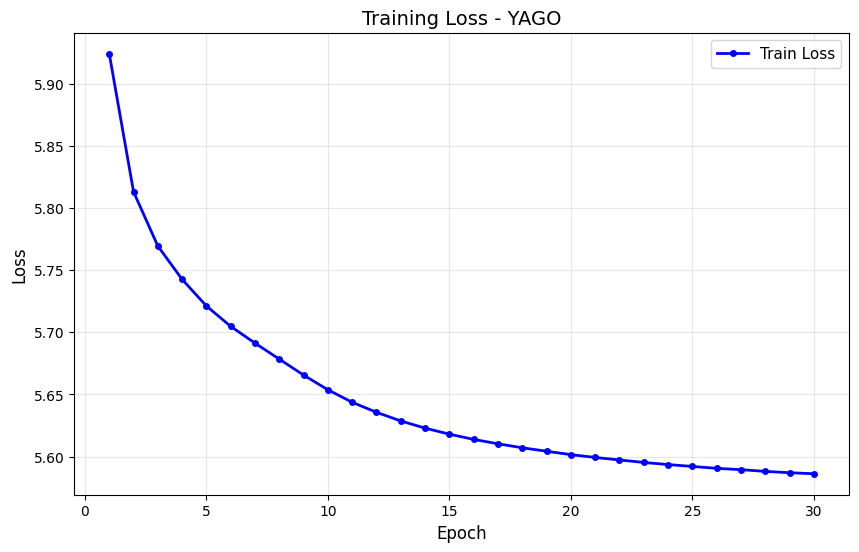

In [44]:
metrics_file = os.path.join(main_dirName, 'metrics.csv')

if os.path.exists(metrics_file):
    # Read metrics from CSV
    df = pd.read_csv(metrics_file)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot training loss
    ax.plot(df['Epoch'], df['Train Loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training Loss - {system_config["dataset"]}', fontsize=14)
    
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Save plot
    plot_file = os.path.join(main_dirName, 'loss_plot.png')
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"Loss plot saved to: {plot_file}")
    
    # Display plot
    plt.show()
else:
    print(f"Metrics file not found: {metrics_file}")

Loss plot saved to: SAVE/version_6_YAGO/val_loss_plot.png


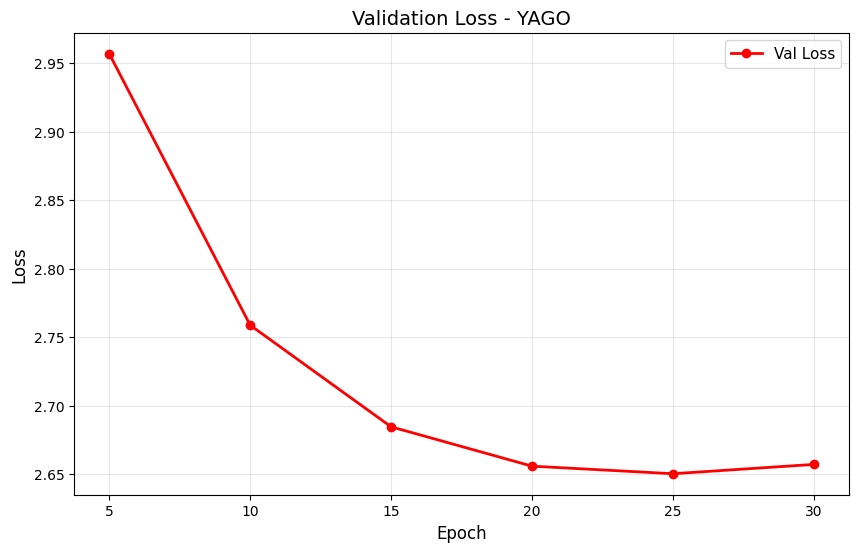

In [45]:
import matplotlib.pyplot as plt

metrics_file = os.path.join(main_dirName, 'metrics.csv')

if os.path.exists(metrics_file):
    # Read metrics from CSV
    df = pd.read_csv(metrics_file)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Filter out NaN values for Val Loss
    valid_data = df.dropna(subset=['Val Loss'])
    
    # Plot validation loss (only non-NaN points)
    ax.plot(valid_data['Epoch'], valid_data['Val Loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Validation Loss - {system_config["dataset"]}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Save plot
    plot_file = os.path.join(main_dirName, 'val_loss_plot.png')

    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    print(f"Loss plot saved to: {plot_file}")
    
    # Display plot
    plt.show()
else:
    print(f"Metrics file not found: {metrics_file}")